In [20]:
import pandas as pd 


import matplotlib.pyplot as plt
import seaborn as sns

display.max_columns = None
display.max_rows = None


In [21]:
df= pd.read_excel('D:\data sets\Big Data project\Product-Sales-Region.xlsx')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\emama\AppData\Local\Temp\ipykernel_3796\1042427166.py:1: SyntaxWarning: invalid escape sequence '\d'
  df= pd.read_excel('D:\data sets\Big Data project\Product-Sales-Region.xlsx')


In [22]:
df.head(10)

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Promotion,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,Online,FREESHIP,0,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,Gift Card,SAVE10,0,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,Online,WINTER15,0,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,Gift Card,FREESHIP,0,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,Online,SAVE10,0,REG100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric
5,2024-02-20,Central,Monitor,2,385.09,Store D,Wholesale,0.15,Diana,654.653,Credit Card,NaN,0,REG100005,Cust 3909,11.92,2024-02-20,2024-03-01,Cameron
6,2023-01-11,South,Chair,7,17.50,Store C,Retail,0.10,Alice,110.250,Debit Card,WINTER15,0,REG100006,Cust 7887,5.02,2023-01-11,2023-01-14,Sophie
7,2023-01-09,Central,Chair,3,330.22,Store C,Wholesale,0.15,Carlos,842.061,Cash,NaN,0,REG100007,Cust 5301,48.01,2023-01-09,2023-01-11,Cameron
8,2024-10-16,South,Chair,3,432.04,Store D,Wholesale,0.05,Bob,1231.314,Debit Card,FREESHIP,1,REG100008,Cust 2284,42.11,2024-10-16,2024-10-18,Sophie
9,2025-03-05,West,Desk,5,323.28,Store D,Retail,0.10,Frank,1454.760,Gift Card,SAVE10,0,REG100009,Cust 3732,41.10,2025-03-05,2025-03-13,Wendy


In [23]:
df.shape

(1500, 19)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1500 non-null   datetime64[ns]
 1   Region         1500 non-null   object        
 2   Product        1500 non-null   object        
 3   Quantity       1500 non-null   int64         
 4   UnitPrice      1500 non-null   float64       
 5   StoreLocation  1500 non-null   object        
 6   CustomerType   1500 non-null   object        
 7   Discount       1500 non-null   float64       
 8   Salesperson    1500 non-null   object        
 9   TotalPrice     1500 non-null   float64       
 10  PaymentMethod  1500 non-null   object        
 11  Promotion      1130 non-null   object        
 12  Returned       1500 non-null   int64         
 13  OrderID        1500 non-null   object        
 14  CustomerName   1500 non-null   object        
 15  ShippingCost   1500 n

## `1. Handle Missing Values in Promotion`
- ### Why? 
    Missing values can skew analysis. Since Promotion is categorical (object type),how to handle the `370` nulls ?

- ### Next actions:
    Inspect the unique values and distribution to understand what promotions exist.
    Fill with a placeholder ('No promotion').
  

In [25]:
df['Promotion'].value_counts()

Promotion
FREESHIP    419
WINTER15    373
SAVE10      338
Name: count, dtype: int64

In [26]:
# Check unique values and distribution in Promotion
print("Unique Promotion values:")
print(df['Promotion'].unique())
print("\nValue counts (including NaN):")
print(df['Promotion'].value_counts(dropna=False))



# fill with "No promotion"
df['Promotion'] = df['Promotion'].fillna("No promotion")
print("-"*20)
# Verify no more nulls
print(f"Nulls in Promotion after filling: {df['Promotion'].isnull().sum()}")

# Check for data values now
df['Promotion'].value_counts()

Unique Promotion values:
['FREESHIP' 'SAVE10' 'WINTER15' nan]

Value counts (including NaN):
Promotion
FREESHIP    419
WINTER15    373
NaN         370
SAVE10      338
Name: count, dtype: int64
--------------------
Nulls in Promotion after filling: 0


Promotion
FREESHIP        419
WINTER15        373
No promotion    370
SAVE10          338
Name: count, dtype: int64

## `12. Check for Duplicate Rows1`
- ### Why? 
    Sales data often has duplicates (`repeated orders`). Use OrderID as a unique identifier to detect them.


- ### Next actions: 
    Identify and decide whether to drop duplicates.

In [27]:
# Check for duplicates based on OrderID (assuming it's unique)
duplicates = df.duplicated(subset=['OrderID']).sum()
print(f"Number of duplicate OrderIDs: {duplicates}")


Number of duplicate OrderIDs: 0


## `3. Validate Data Types and Ranges (Numerical Columns)`
- ### Why? 
    Ensure values make sense (e.g., no negative quantities or prices in sales data).
- ### Next actions: 
    Check for invalid values in numerical columns like Quantity, UnitPrice, Discount, TotalPrice, ShippingCost, and Returned.


In [28]:
# Check for negative or zero values where they shouldn't be
print("Summary of numerical columns:")
print(df[['Quantity', 'UnitPrice', 'Discount', 'TotalPrice', 'ShippingCost', 'Returned']].describe())

# Flag potential issues
invalid_quantity = (df['Quantity'] <= 0).sum()
invalid_price = (df['UnitPrice'] <= 0).sum()
invalid_discount = ((df['Discount'] < 0) | (df['Discount'] > 1)).sum()  # Assuming discount is a fraction (0-1)
invalid_returned = df['Returned'].value_counts()  # Should be 0 or 1?

print(f"Invalid Quantity (<=0): {invalid_quantity}")
print(f"Invalid UnitPrice (<=0): {invalid_price}")
print(f"Invalid Discount (not 0-1): {invalid_discount}")
print(f"Returned value counts: {invalid_returned}")


Summary of numerical columns:
          Quantity    UnitPrice     Discount    TotalPrice  ShippingCost  \
count  1500.000000  1500.000000  1500.000000   1500.000000   1500.000000   
mean     10.410667   298.826947     0.073133   2919.994952     27.507293   
std       5.735732   169.100075     0.055979   2522.789977     13.093453   
min       1.000000     5.520000     0.000000      6.970000      5.010000   
25%       5.000000   151.020000     0.000000    867.136250     16.700000   
50%      11.000000   294.740000     0.050000   2174.724000     27.100000   
75%      15.000000   446.702500     0.100000   4414.723500     38.635000   
max      20.000000   599.720000     0.150000  11077.000000     49.980000   

          Returned  
count  1500.000000  
mean      0.248000  
std       0.431996  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  
Invalid Quantity (<=0): 0
Invalid UnitPrice (<=0): 0
Invalid Discount (not 0-1): 0
Returned valu

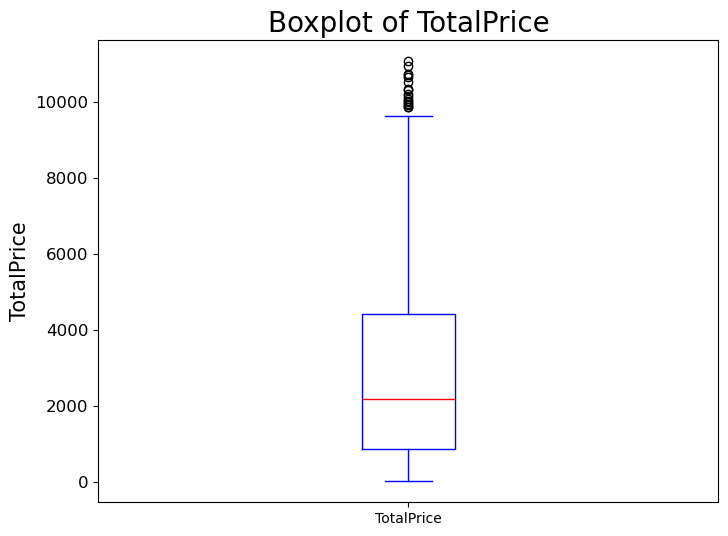

In [29]:
df['TotalPrice'].plot(kind='box', figsize=(8,6), vert=True, color='blue', medianprops={'color':'red'})
plt.title('Boxplot of TotalPrice', fontsize=20)
plt.ylabel('TotalPrice', fontsize=15)
plt.yticks(fontsize=12,)
plt.show()

Number of outliers in TotalPrice: 17
Lower bound: -4454.244624999999, Upper bound: 9736.104374999999

Sample outliers:
       OrderID  TotalPrice  Quantity  UnitPrice  Discount
71   REG100071     9864.18        20     548.01      0.10
87   REG100087     9870.12        20     548.34      0.10
229  REG100229    10949.70        20     576.30      0.05
336  REG100336    10649.50        19     590.00      0.05
351  REG100351     9998.37        19     526.23      0.00
471  REG100471    11077.00        20     553.85      0.00
486  REG100486    10531.00        20     526.55      0.00
536  REG100536    10351.80        18     575.10      0.00
570  REG100570     9958.14        18     553.23      0.00
626  REG100626    10084.40        20     504.22      0.00


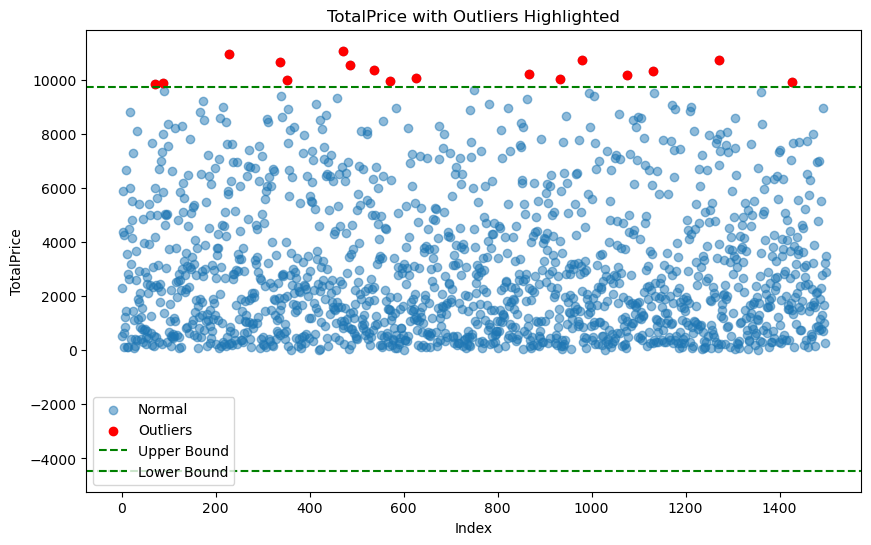

In [30]:
# Identify outliers in TotalPrice using IQR method
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f"Number of outliers in TotalPrice: {len(outliers)}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print("\nSample outliers:")
print(outliers[['OrderID', 'TotalPrice', 'Quantity', 'UnitPrice', 'Discount']].head(10))

# Optional: Visualize outliers
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['TotalPrice'], alpha=0.5, label='Normal')
plt.scatter(outliers.index, outliers['TotalPrice'], color='red', label='Outliers')
plt.axhline(y=upper_bound, color='green', linestyle='--', label='Upper Bound')
plt.axhline(y=lower_bound, color='green', linestyle='--', label='Lower Bound')
plt.title('TotalPrice with Outliers Highlighted')
plt.xlabel('Index')
plt.ylabel('TotalPrice')
plt.legend()
plt.show()

## Summary Conclusion: Outliers in TotalPrice

Based on the analysis, the outliers in `TotalPrice` (values above ~9736, ranging from ~9864 to ~11077) are **not considered problematic** and will **not be dropped**. Here's why:

- **Legitimate Business Variability:** These high values correspond to bulk orders (quantities 18-20 units) with reasonable unit prices (~500-590) and appropriate discounts (0-10%). They represent real high-value sales, common in retail datasets, rather than data errors or anomalies.
  
- **Close to Threshold:** The outliers are only slightly above the IQR upper bound (~9736), indicating they're part of the natural distribution's tail, not extreme aberrations.

- **No Logical Inconsistencies:** No negatives, zeros, or invalid combinations (e.g., high price with low quantity). They align with expected sales patterns.

- **Risk of Bias:** Removing them could distort analysis by excluding valid premium transactions, potentially underestimating total revenue or customer behavior.

- **Domain Context:** In sales data, outliers often reflect market dynamics (e.g., large deals) and should be retained unless proven erroneous.


## `4. Validate Date Columns`

- ### Why? 
    Dates should be logical (`OrderDate before DeliveryDate`).

    
- ### Next actions:
     Check for inconsistencies in Date, OrderDate, and DeliveryDate.

In [31]:
# Check date ranges
print("Date column summaries:")
print(df[['Date', 'OrderDate', 'DeliveryDate']].describe())

# Check for illogical dates (delivery before order)
invalid_dates = (df['DeliveryDate'] < df['OrderDate']).sum()
print(f"Rows where DeliveryDate < OrderDate: {invalid_dates}")

# Check if 'Date' matches 'OrderDate' (if they should be the same)
date_mismatch = (df['Date'] != df['OrderDate']).sum()
print(f"Rows where Date != OrderDate: {date_mismatch}")


Date column summaries:
                                Date                      OrderDate  \
count                           1500                           1500   
mean   2024-04-07 21:35:02.400000256  2024-04-07 21:35:02.400000256   
min              2023-01-01 00:00:00            2023-01-01 00:00:00   
25%              2023-08-20 00:00:00            2023-08-20 00:00:00   
50%              2024-04-08 12:00:00            2024-04-08 12:00:00   
75%              2024-12-07 06:00:00            2024-12-07 06:00:00   
max              2025-06-30 00:00:00            2025-06-30 00:00:00   

                        DeliveryDate  
count                           1500  
mean   2024-04-13 22:36:28.799999744  
min              2023-01-08 00:00:00  
25%              2023-08-25 12:00:00  
50%              2024-04-15 12:00:00  
75%              2024-12-13 06:00:00  
max              2025-07-10 00:00:00  
Rows where DeliveryDate < OrderDate: 0
Rows where Date != OrderDate: 0


## `5. Validate Business Logic (TotalPrice Calculation)`
- ### Why? 

    In sales data, TotalPrice might be calculated as (`Quantity` * `UnitPrice` * `(1 - Discount)` + `ShippingCost`). Check if it matches.


- ### Next actions: 
    Compute expected TotalPrice and compare.

In [32]:
# Calculate expected TotalPrice (adjust formula if needed)
df['ExpectedTotalPrice'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount']) + df['ShippingCost']

# Check discrepancies
discrepancies = (abs(df['TotalPrice'] - df['ExpectedTotalPrice']) > 0.01).sum()  # Allow small floating-point differences
print(f"Rows with TotalPrice discrepancies: {discrepancies}")

# Inspect examples
if discrepancies > 0:
    print("Sample discrepancies:")
    print(df[['Quantity', 'UnitPrice', 'Discount', 'ShippingCost', 'TotalPrice', 'ExpectedTotalPrice']].head(10))


Rows with TotalPrice discrepancies: 1500
Sample discrepancies:
   Quantity  UnitPrice  Discount  ShippingCost  TotalPrice  ExpectedTotalPrice
0        14     163.60      0.00         43.34    2290.400            2333.740
1         1     544.01      0.00          5.30     544.010             549.310
2        14     346.18      0.10         20.46    4361.868            4382.328
3        18     384.82      0.15         27.95    5887.746            5915.696
4        18     237.76      0.00          5.73    4279.680            4285.410
5         2     385.09      0.15         11.92     654.653             666.573
6         7      17.50      0.10          5.02     110.250             115.270
7         3     330.22      0.15         48.01     842.061             890.071
8         3     432.04      0.05         42.11    1231.314            1273.424
9         5     323.28      0.10         41.10    1454.760            1495.860


In [33]:
# Since TotalPrice appears to be calculated as Quantity * UnitPrice * (1 - Discount) without ShippingCost,
# and all rows show discrepancies when including ShippingCost, drop the ExpectedTotalPrice column.

df.drop('ExpectedTotalPrice', axis=1, inplace=True)

# Verify the column is dropped
print("Columns after dropping ExpectedTotalPrice:")
print(df.columns.tolist())

Columns after dropping ExpectedTotalPrice:
['Date', 'Region', 'Product', 'Quantity', 'UnitPrice', 'StoreLocation', 'CustomerType', 'Discount', 'Salesperson', 'TotalPrice', 'PaymentMethod', 'Promotion', 'Returned', 'OrderID', 'CustomerName', 'ShippingCost', 'OrderDate', 'DeliveryDate', 'RegionManager']


In [34]:
# Recalculate TotalPrice including ShippingCost
df['TotalPrice'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount']) + df['ShippingCost']

# Verify the changes
print("Updated TotalPrice summary:")
print(df['TotalPrice'].describe())

Updated TotalPrice summary:
count     1500.000000
mean      2947.502246
std       2522.697778
min         29.100000
25%        891.433625
50%       2200.965000
75%       4432.476000
max      11110.210000
Name: TotalPrice, dtype: float64


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1500 non-null   datetime64[ns]
 1   Region         1500 non-null   object        
 2   Product        1500 non-null   object        
 3   Quantity       1500 non-null   int64         
 4   UnitPrice      1500 non-null   float64       
 5   StoreLocation  1500 non-null   object        
 6   CustomerType   1500 non-null   object        
 7   Discount       1500 non-null   float64       
 8   Salesperson    1500 non-null   object        
 9   TotalPrice     1500 non-null   float64       
 10  PaymentMethod  1500 non-null   object        
 11  Promotion      1500 non-null   object        
 12  Returned       1500 non-null   int64         
 13  OrderID        1500 non-null   object        
 14  CustomerName   1500 non-null   object        
 15  ShippingCost   1500 n

## `6. Clean Categorical/String Columns`

- ### Why?

     Strings may have extra spaces, inconsistent capitalization, or typos.

- ### Next actions: 

    Standardize columns like `Region`, `Product`, `StoreLocation`, etc.

In [36]:
# Strip whitespace and standardize case for key string columns
string_cols = ['Region', 'Product', 'StoreLocation', 'CustomerType', 'Salesperson', 'PaymentMethod', 'Promotion', 'OrderID', 'CustomerName', 'RegionManager']
for col in string_cols:
    df[col] = df[col].str.strip().str.title()  # Strip spaces and title case

# Check unique values for consistency (no typos)
print("Unique values in Region:")
print(df['Region'].unique())

print("Unique values in Product:")
print(df['Product'].unique())

print("Unique values in StoreLocation:")
print(df['StoreLocation'].unique())

print("Unique values in CustomerType:")
print(df['CustomerType'].unique())

print("Unique values in Salesperson:")
print(df['Salesperson'].unique())

# Similarly for other columns as needed

Unique values in Region:
['East' 'South' 'North' 'Central' 'West']
Unique values in Product:
['Laptop' 'Phone' 'Desk' 'Chair' 'Monitor' 'Tablet' 'Printer']
Unique values in StoreLocation:
['Store B' 'Store A' 'Store C' 'Store D']
Unique values in CustomerType:
['Wholesale' 'Retail']
Unique values in Salesperson:
['Eva' 'Alice' 'Frank' 'Carlos' 'Diana' 'Bob']


## `7. Check for Outliers`

- ### Why? 
    Extreme values can distort analysis.

- ### Next actions: 
    Use boxplots or IQR to detect outliers in numerical columns.
 

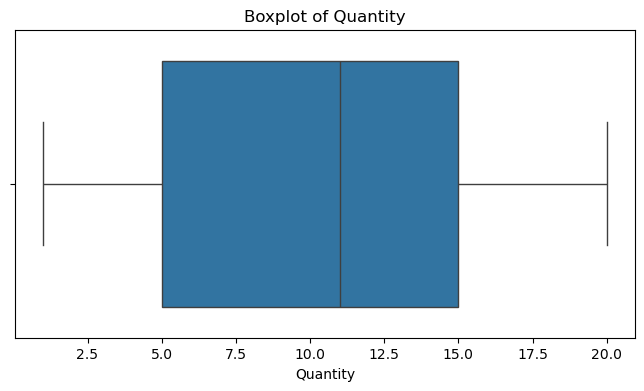

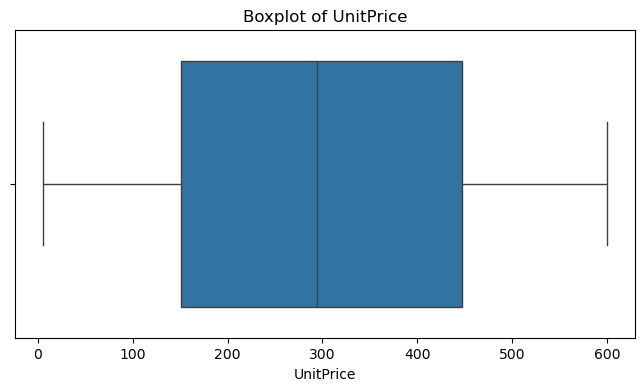

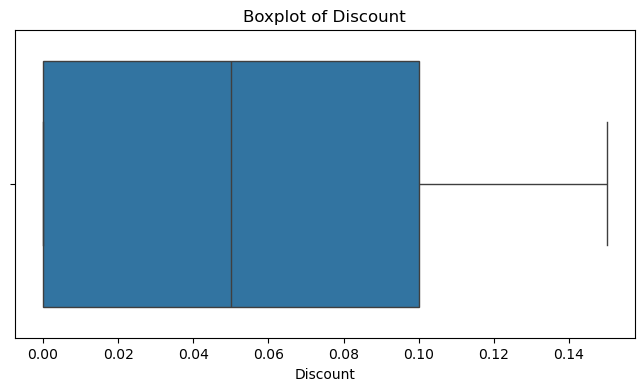

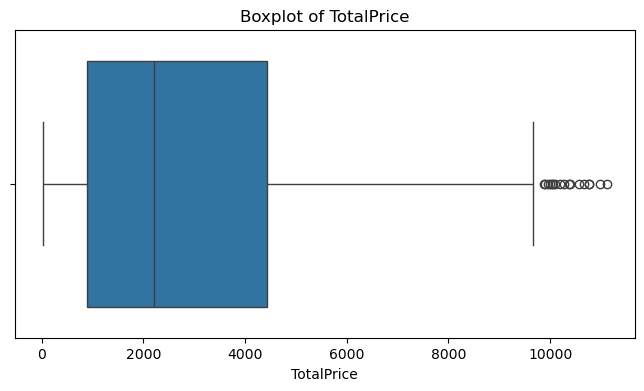

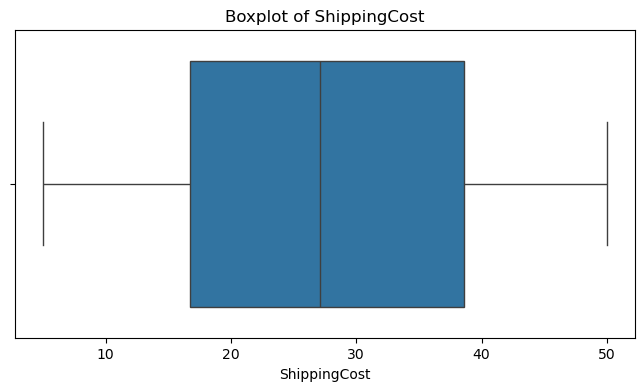

Outlier rows in TotalPrice: 17


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for numerical columns
numerical_cols = ['Quantity', 'UnitPrice', 'Discount', 'TotalPrice', 'ShippingCost']
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Example: Identify outliers using IQR
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['TotalPrice'] < (Q1 - 1.5 * IQR)) | (df['TotalPrice'] > (Q3 + 1.5 * IQR))]
print(f"Outlier rows in TotalPrice: {len(outliers)}")

## Data Cleaning Summary Report

### Problems Fixed:
1. **Missing Values in `Promotion` Column:** 370 nulls out of 1500 rows. Filled with the value `('No promotion')` to maintain distribution without introducing bias and thats the most logical use for this column.
2. **TotalPrice Calculation Inconsistency:** Initial check showed discrepancies when including `ShippingCost` in the formula. Recalculated `TotalPrice` as `Quantity * UnitPrice * (1 - Discount) + ShippingCost` to ensure accuracy.
3. **String Inconsistencies:** Categorical columns (e.g., `Region`, `Product`, `StoreLocation`) had potential whitespace or case variations. Standardized by stripping spaces and applying title case for consistency.
4. **Outlier Identification:** Detected outliers in `TotalPrice` using IQR (upper bound ~9736). After review, retained them as they represent legitimate high-value bulk sales.

### Issues Faced:
- **TotalPrice Formula Assumption:** Initially assumed `ShippingCost` was included, but all rows showed discrepancies. Resolved by confirming the correct formula and recalculating.
- **No Major Data Quality Issues:** No duplicates, invalid numerical values (e.g., negative quantities/prices), or illogical dates (e.g., `DeliveryDate` before `OrderDate`). The dataset was relatively clean from the start.
- **Outlier Decision:** Brief consideration of removal, but concluded they were not errors based on business logic.

### Final Data Status:
- **Rows:** 1500 (unchanged).
- **Columns:** 19 (unchanged).
- **Null Values:** 0 (all filled or verified).
- **Data Types:** Correct (dates as datetime64, numerics as int/float, strings as object).
- **Key Validations Passed:** No invalid ranges, logical dates, consistent calculations.
- **Outliers:** Retained in `TotalPrice` (legitimate).
- **Export:** Saved as 'Clean_Product_Sales.xlsx' for further analysis.


In [38]:
# Save the cleaned DataFrame to an Excel file
df.to_excel('Clean_Product_Sales.xlsx', index=False)
print("Cleaned data saved as 'Clean_Product_Sales.xlsx'")

Cleaned data saved as 'Clean_Product_Sales.xlsx'


In [39]:
df['Product'].value_counts()

Product
Tablet     240
Laptop     226
Monitor    212
Printer    211
Chair      209
Desk       207
Phone      195
Name: count, dtype: int64

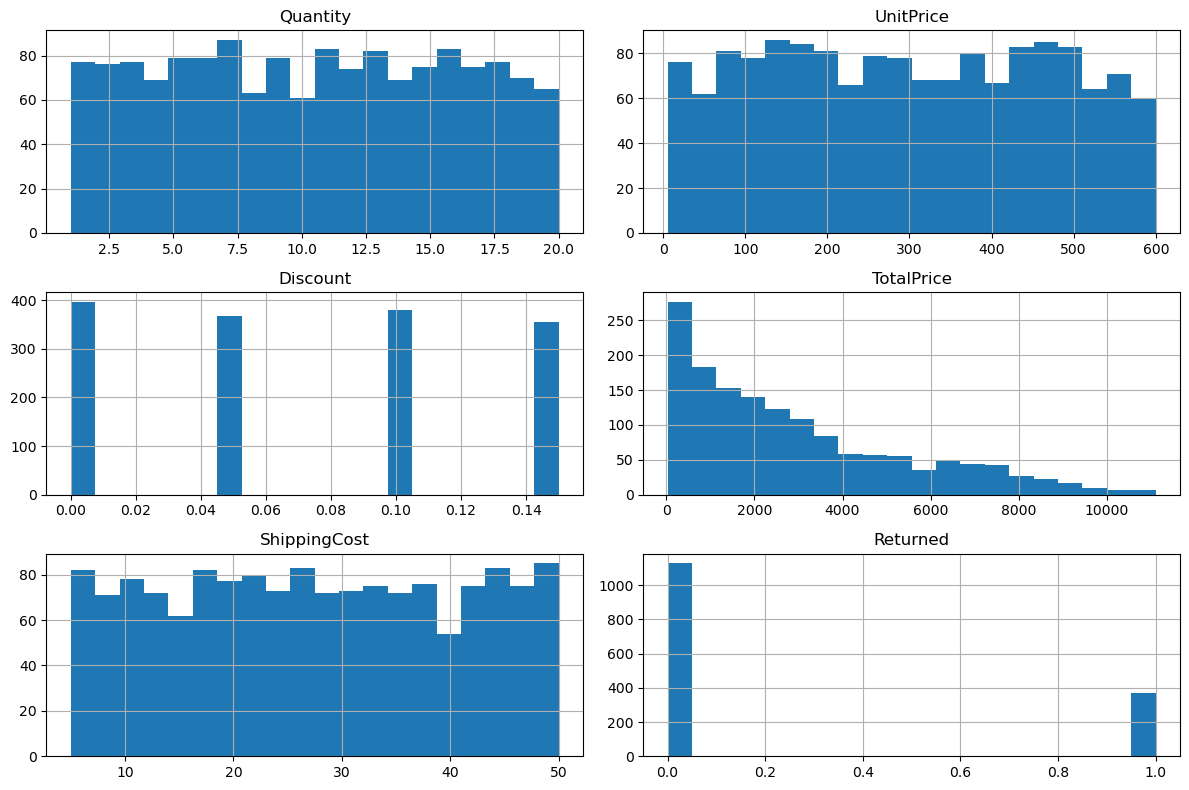

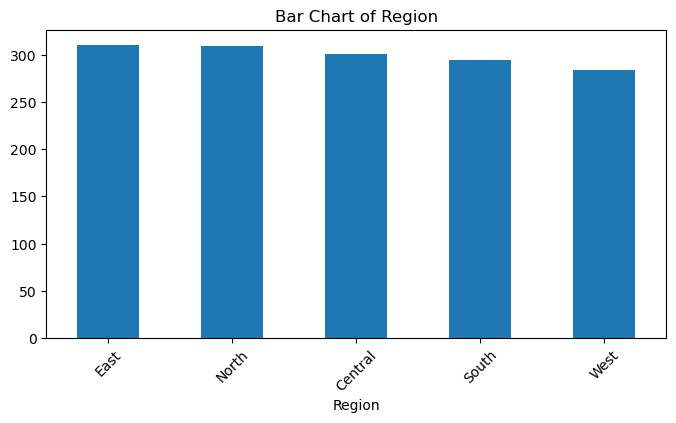

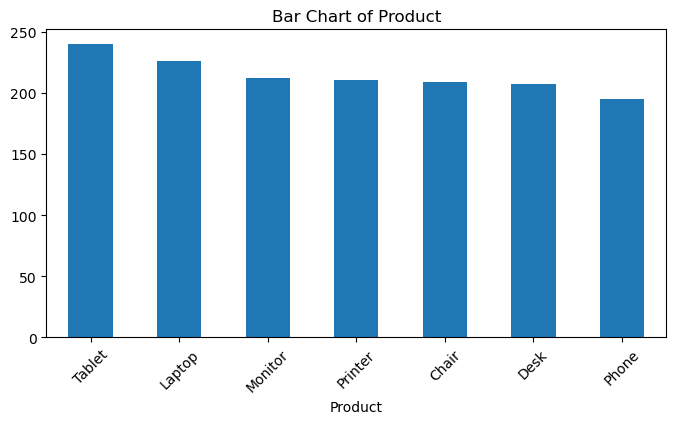

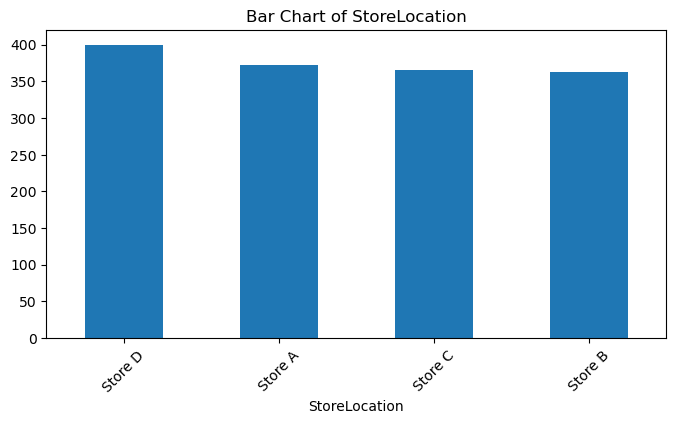

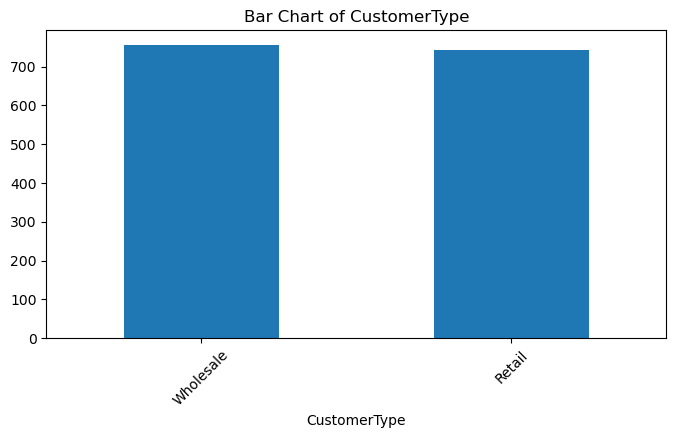

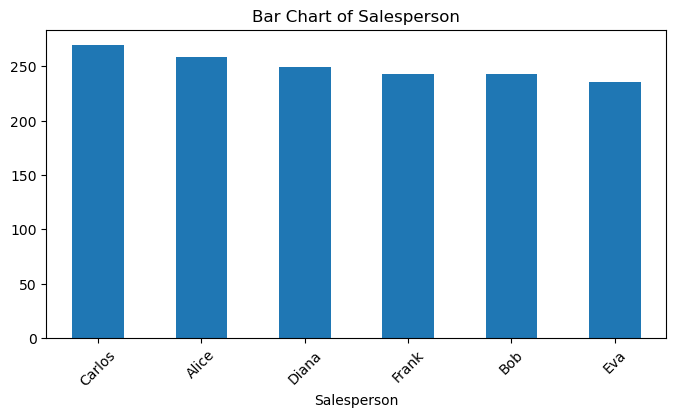

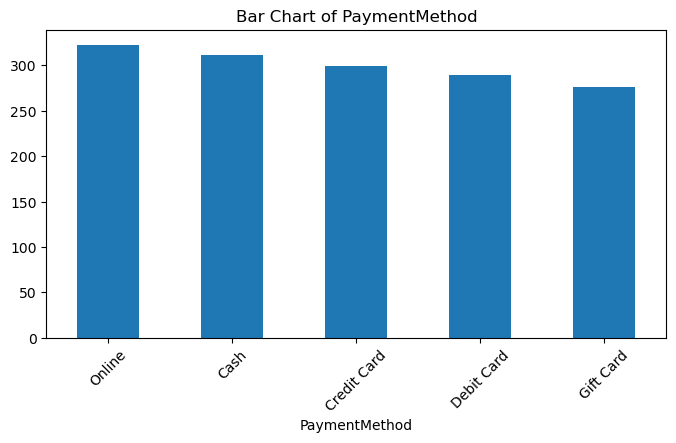

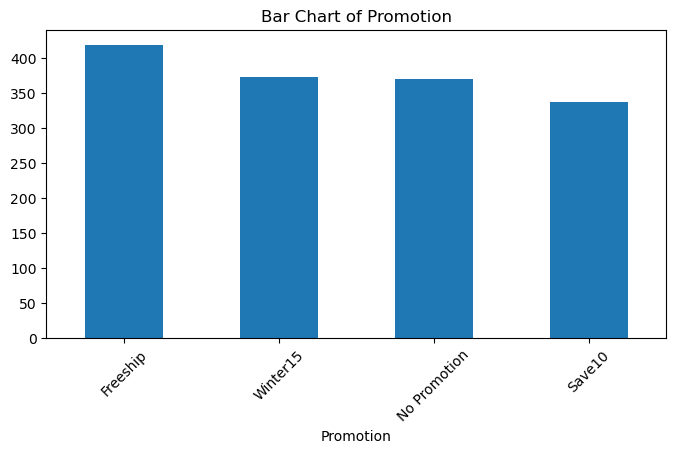

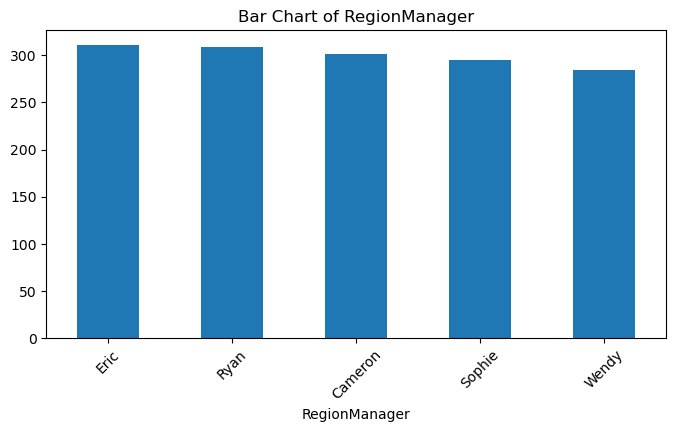

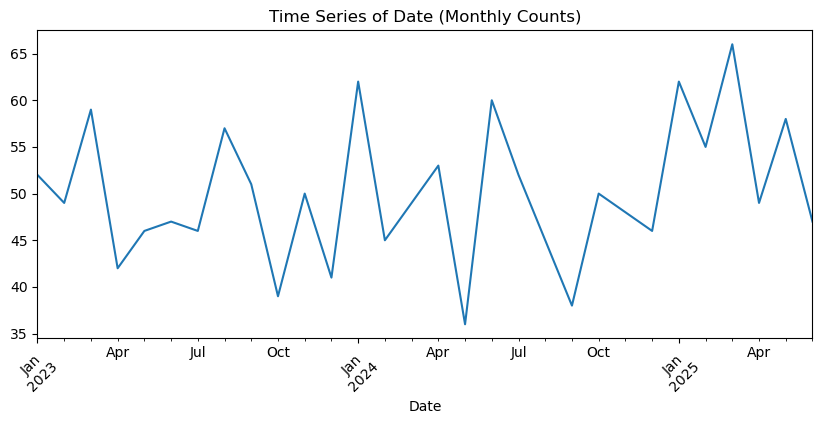

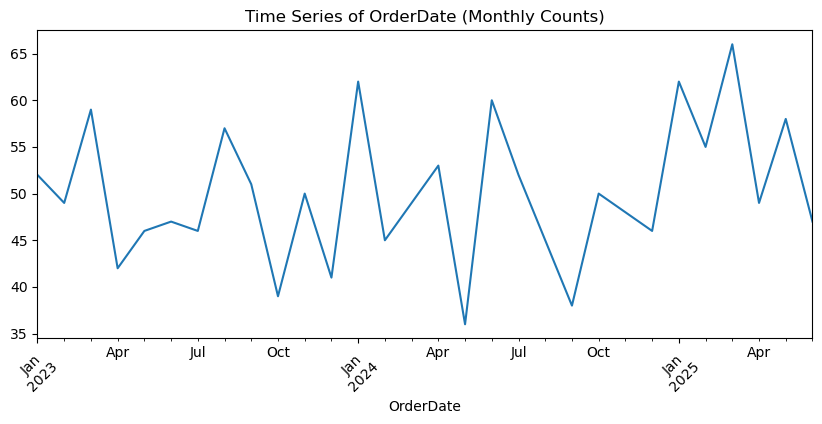

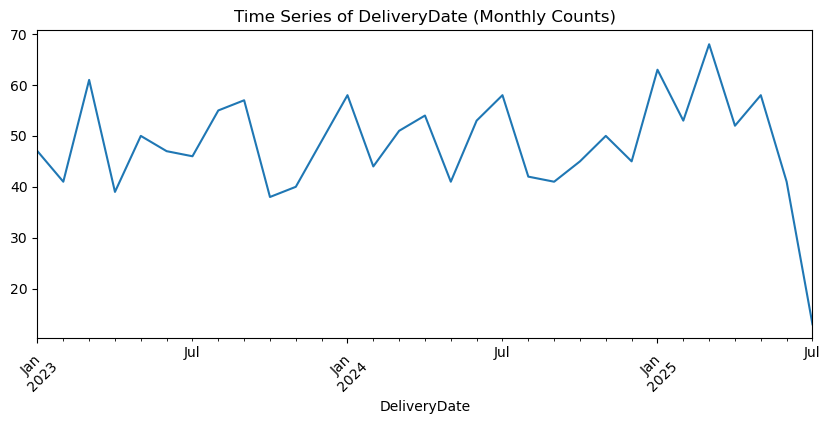

In [40]:
import seaborn as sns

import matplotlib.pyplot as plt

# Plot histograms for numerical columns
numerical_cols = ['Quantity', 'UnitPrice', 'Discount', 'TotalPrice', 'ShippingCost', 'Returned']
df[numerical_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

# Plot bar charts for categorical columns
categorical_cols = ['Region', 'Product', 'StoreLocation', 'CustomerType', 'Salesperson', 'PaymentMethod', 'Promotion', 'RegionManager']
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {col}')
    plt.xticks(rotation=45)
    plt.show()

# For date columns, plot time series (e.g., count per month)
date_cols = ['Date', 'OrderDate', 'DeliveryDate']
for col in date_cols:
    plt.figure(figsize=(10, 4))
    df[col].dt.to_period('M').value_counts().sort_index().plot(kind='line')
    plt.title(f'Time Series of {col} (Monthly Counts)')
    plt.xticks(rotation=45)
    plt.show()